# 🟡 미션 3 (~25분) — 출력 시점마다 보는 곳이 옮겨 가나?

오전에 이렇게 말했습니다: *"가중치는 출력할 때마다 달라야 한다."*
출력 글자 하나하나의 가중치를 **막대그래프로 나열**해 확인합니다.

제출: `my_weights_by_step.png` + "어느 출력에서 어디로 옮겨 갔나" **한 줄**.

In [1]:
import sys
# 노트북(cwd=이 폴더)에서도, .py 를 상위에서 돌려도 attn/koplot 을 찾게 한다.
# ⚠️ __file__ 은 주피터 커널에 정의되지 않는다 — 노트북에서 NameError 로 죽는다.
sys.path[:0] = ["..", "."]

import matplotlib
# 노트북이면 그림이 셀 아래에 바로 뜬다. 터미널이면 화면 없이 파일로만 저장한다.
NOTEBOOK = "ipykernel" in sys.modules
if not NOTEBOOK:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import koplot; koplot.use_korean()

from dates import DateData
from model import train, translate

data = DateData(n=8000, seed=0)
enc, dec = train(data, epochs=6)

[koplot] 한글 폰트 적용: NanumGothic
  epoch 0  loss 1.849  (2.4s)
  epoch 1  loss 0.993  (4.6s)
  epoch 2  loss 0.551  (6.9s)
  epoch 3  loss 0.227  (9.2s)
  epoch 4  loss 0.051  (11.5s)
  epoch 5  loss 0.016  (13.8s)


In [2]:
MY_DATE = "28 July 2026"     # TODO: 재정렬 포맷의 내 날짜로

pred, A = translate(enc, dec, data, MY_DATE)
print(f"{MY_DATE} -> {pred}")

28 July 2026 -> 2026-07-28


## 출력 글자 4개를 골라 가중치를 막대로
`PICKS`는 **출력**의 몇 번째 글자인지입니다. (0부터)

저장: my_weights_by_step.png


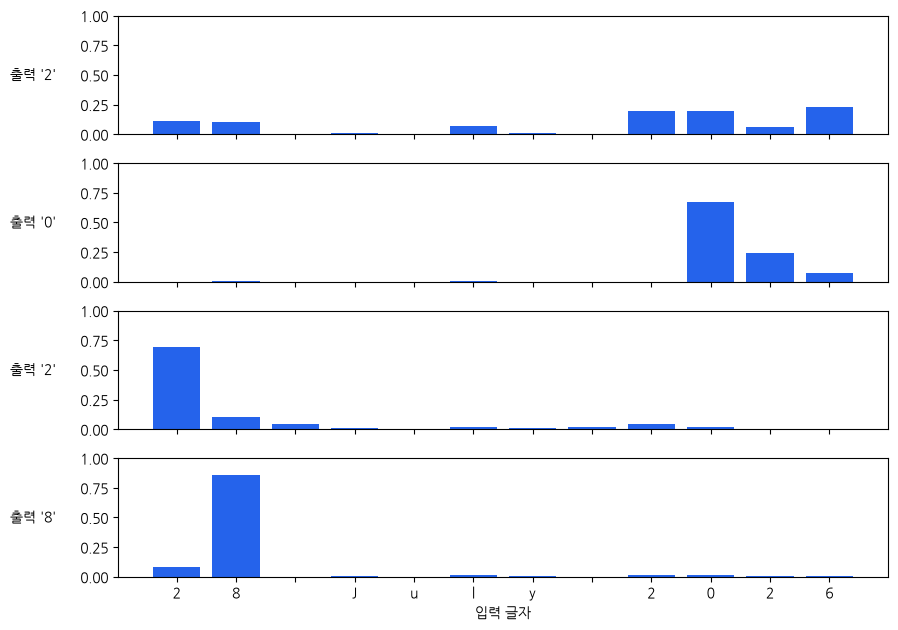

In [3]:
PICKS = [0, 1, 8, 9]         # TODO: 보고 싶은 출력 위치로 바꿔도 좋다

xs = np.arange(len(MY_DATE))
fig, axes = plt.subplots(len(PICKS), 1, figsize=(9, 6.4), sharex=True)
for ax, i in zip(axes, PICKS):
    ax.bar(xs, A[i], color="#2563eb")
    ax.set_ylabel(f"출력 '{pred[i]}'", rotation=0, labelpad=34, va="center")
    ax.set_ylim(0, 1.0)
axes[-1].set_xticks(xs); axes[-1].set_xticklabels(list(MY_DATE))
axes[-1].set_xlabel("입력 글자")
plt.tight_layout()
plt.savefig("my_weights_by_step.png", dpi=120)
print("저장: my_weights_by_step.png")
if not NOTEBOOK:
    plt.close()                # 노트북에서는 닫지 않는다 — 닫으면 셀에 안 보인다

# TODO(쓰기): 출력이 진행되면서 막대가 어디에서 어디로 옮겨 갔나? 한 줄.
# 출력의 앞쪽 연도 글자('2', '0')를 생성할 때는 입력의 맨 뒤 연도 영역('2026')을 바라보다가, 
# 뒤쪽 일자 글자('2', '8')를 생성할 때는 입력의 맨 앞 일자 영역('28')으로 어텐션 가중치가 시점별로 유연하게 이동함